<a href="https://colab.research.google.com/github/anelriera/ibex_data/blob/main/mongosdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Environment Setup and MongoDB Connection

In [ ]:
# Install necessary libraries
!pip install pymongo yfinance pandas

import os
import datetime
import pandas as pd
import yfinance as yf
from pymongo import MongoClient
from google.colab import userdata # For securely loading MONGO_URI in Colab

# Load MongoDB connection string from Colab secrets
MONGO_URI = userdata.get('MONGO_URI')

# Check if MONGO_URI was loaded (for error logging if not found)
if not MONGO_URI:
    print("ERROR: MONGO_URI not found. Please add it to Colab Secrets.")

In [11]:
# Connect to MongoDB Atlas
try:
    client = MongoClient(MONGO_URI)
    db = client.ibex_db
    collection = db.daily_snapshots
except Exception as e:
    print(f"ERROR: Failed to connect to MongoDB: {e}")

In [21]:
ibex_tickers = [
    "ACS.MC", "ACX.MC", "AENA.MC", "ALM.MC", "AMS.MC", "ANA.MC", "BBVA.MC", "BKT.MC",
    "CABK.MC", "CLNX.MC", "ELE.MC", "ENG.MC", "FER.MC", "FDR.MC", "GRF.MC",
    "IBE.MC", "IDR.MC", "ITX.MC", "MAP.MC", "MEL.MC", "MRL.MC",
    "MTS.MC", "NTGY.MC", "RED.MC", "REP.MC", "ROVI.MC", "SAB.MC", "SAN.MC", "SLR.MC",
    "ANE.MC", "TEF.MC", "UNI.MC", "VIS.MC", "COL.MC", "PUIG.MC"
]

snapshot_date = datetime.datetime.now()
daily_snapshots_data = []

for ticker_symbol in ibex_tickers:
    try:
        ticker = yf.Ticker(ticker_symbol)
        hist = ticker.history(period="1y")

        if hist.empty:
            print(f"WARNING: No historical data found for {ticker_symbol}. Skipping.")
            continue

        info = ticker.info
        sector = info.get('sector', 'N/A')
        market_cap = info.get('marketCap', 0)

        last_close = hist['Close'].iloc[-1]

        daily_variation = (last_close - hist['Close'].iloc[-2]) / hist['Close'].iloc[-2] * 100 if len(hist) >= 2 else 0.0
        weekly_variation = (last_close - hist['Close'].iloc[-5]) / hist['Close'].iloc[-5] * 100 if len(hist) >= 5 else 0.0
        monthly_variation = (last_close - hist['Close'].iloc[-21]) / hist['Close'].iloc[-21] * 100 if len(hist) >= 21 else 0.0

        returns = hist['Close'].pct_change().dropna()
        annualized_volatility = returns.std() * (252**0.5) * 100 if not returns.empty else 0.0

        if market_cap >= 200 * 10**9:
            market_cap_category = 'Mega Cap'
        elif market_cap >= 10 * 10**9:
            market_cap_category = 'Large Cap'
        elif market_cap >= 2 * 10**9:
            market_cap_category = 'Mid Cap'
        elif market_cap >= 300 * 10**6:
            market_cap_category = 'Small Cap'
        else:
            market_cap_category = 'Micro Cap'

        daily_snapshots_data.append({
            "snapshot_date": snapshot_date,
            "symbol": ticker_symbol,
            "last_close_price": round(last_close, 2),
            "daily_variation_pct": round(daily_variation, 2),
            "weekly_variation_pct": round(weekly_variation, 2),
            "monthly_variation_pct": round(monthly_variation, 2),
            "annualized_volatility_pct": round(annualized_volatility, 2),
            "sector": sector,
            "market_cap": market_cap,
            "market_cap_category": market_cap_category
        })

    except Exception as e:
        print(f"ERROR: Failed to process {ticker_symbol}: {e}")

ERROR:yfinance:HTTP Error 500: {"quoteSummary":{"result":null,"error":{"code":"internal-error","description":"internal-error"}}}


### IBEX 35 Financial Data Extraction

In [22]:
if daily_snapshots_data:
    try:
        result = collection.insert_many(daily_snapshots_data)
    except Exception as e:
        print(f"ERROR: Failed to insert documents into MongoDB: {e}")

### MongoDB Snapshot Ingestion

In [23]:
# Define time range for today's snapshot
start_of_day = snapshot_date.replace(hour=0, minute=0, second=0, microsecond=0)
end_of_day = snapshot_date.replace(hour=23, minute=59, second=59, microsecond=999999)

# Fetch all documents for today's snapshot into a DataFrame once
df_today = pd.DataFrame(list(collection.find({
    "snapshot_date": {"$gte": start_of_day, "$lte": end_of_day}
})))

if not df_today.empty:
    display(df_today[['symbol', 'last_close_price', 'daily_variation_pct']].head())

,symbol,last_close_price,daily_variation_pct
0,ACS.MC,123.20,1.57
1,ACX.MC,13.49,-0.52
2,AENA.MC,25.92,-0.99
3,ALM.MC,12.86,1.10
4,AMS.MC,50.92,-3.27


### IBEX 35 Market Data Analysis

In [24]:
df_high_daily_var = df_today[df_today['daily_variation_pct'] > 1].sort_values("daily_variation_pct", ascending=False)

if not df_high_daily_var.empty:
    display(df_high_daily_var[['symbol', 'daily_variation_pct']].head())

,symbol,daily_variation_pct
27,SLR.MC,3.27
96,SLR.MC,2.64
61,SLR.MC,2.51
23,REP.MC,2.32
92,REP.MC,2.08


In [25]:
target_sector = "Financial Services"

df_sector = df_today[df_today['sector'] == target_sector]

if not df_sector.empty:
    display(df_sector[['symbol', 'sector', 'daily_variation_pct']].head())

,symbol,sector,daily_variation_pct
6,BBVA.MC,Financial Services,-1.25
7,BKT.MC,Financial Services,-0.17
8,CABK.MC,Financial Services,-1.62
18,MAP.MC,Financial Services,-0.14
25,SAB.MC,Financial Services,-1.58


In [26]:
pipeline = [
    {"$match": {"snapshot_date": {"$gte": start_of_day, "$lte": end_of_day}}},
    {"$group": {
        "_id": "$sector",
        "average_volatility": {"$avg": "$annualized_volatility_pct"},
        "company_count": {"$sum": 1}
    }},
    {"$sort": {"average_volatility": -1}}
]

df_sector_volatility = pd.DataFrame(list(collection.aggregate(pipeline)))

if not df_sector_volatility.empty:
    display(df_sector_volatility.head())

,_id,average_volatility,company_count
0,Technology,36.160000,6
1,Basic Materials,33.052000,5
2,N/A,32.226667,3
3,Energy,28.100000,3
4,Healthcare,27.145556,9


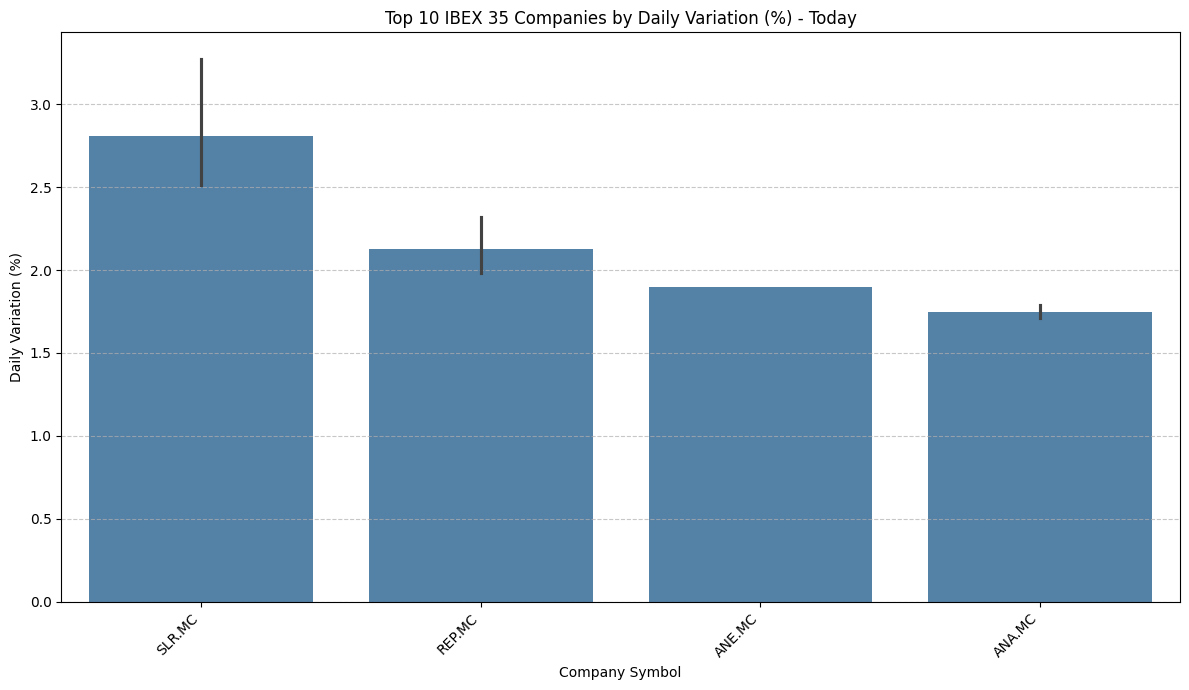

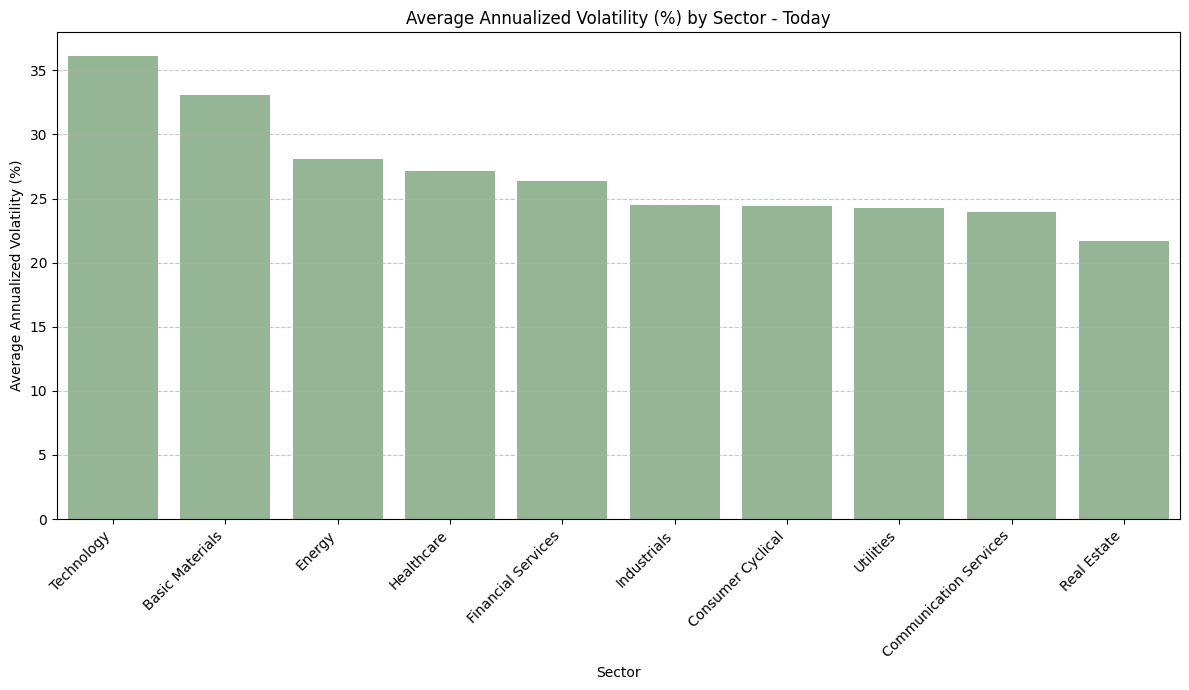

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

if df_today.empty:
    print("WARNING: No data available from today's snapshot for visualizations.")
else:
    # Plot 1: Top 10 companies by daily variation
    plt.figure(figsize=(12, 7))
    top_10_daily_var = df_today.sort_values(by='daily_variation_pct', ascending=False).head(10)
    # Use a single, professional color for the bar plot, fixing FutureWarning
    sns.barplot(x='symbol', y='daily_variation_pct', data=top_10_daily_var, color='steelblue')
    plt.title('Top 10 IBEX 35 Companies by Daily Variation (%) - Today')
    plt.xlabel('Company Symbol')
    plt.ylabel('Daily Variation (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    if not df_sector_volatility.empty:
        # Filter out 'N/A' sectors before plotting
        df_sector_volatility_filtered = df_sector_volatility[df_sector_volatility['_id'] != 'N/A']
        if not df_sector_volatility_filtered.empty:
            plt.figure(figsize=(12, 7))
            # Use a single, professional color for the bar plot, fixing FutureWarning
            sns.barplot(x='_id', y='average_volatility', data=df_sector_volatility_filtered, color='darkseagreen')
            plt.title('Average Annualized Volatility (%) by Sector - Today')
            plt.xlabel('Sector')
            plt.ylabel('Average Annualized Volatility (%)')
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
        else:
            print("WARNING: No sector volatility data available after filtering for 'N/A' sectors.")
    else:
        print("WARNING: No sector volatility data for visualization.")